# <b> 라이브러리 임포트

In [35]:
import requests
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

from IPython.display import display

print("라이브러리 임포트 완료! ✅")

라이브러리 임포트 완료! ✅


# <b> 네이버 쇼핑 API

In [36]:
CLIENT_ID = "QxAHnj74KXnq3XmHZ6EN"
CLIENT_SECRET = "P8T2W2KudH"

URL = "https://openapi.naver.com/v1/search/shop.json"

HEADERS = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET
}

# 카테고리 설정
CATEGORIES = {
    "컵라면"  : "컵라면",
    "봉지라면" : "봉지라면",
    "즉석밥"  : "즉석밥",
    "컵밥"   : "컵밥",
    "레토르트" : "레토르트",
    "냉동만두" : "냉동만두",
    "간편식"  : "간편식",
    "생수"   : "생수"
}

print("API 설정 완료! ✅")
print(f"카테고리 {len(CATEGORIES)}개: {list(CATEGORIES.keys())}")

API 설정 완료! ✅
카테고리 8개: ['컵라면', '봉지라면', '즉석밥', '컵밥', '레토르트', '냉동만두', '간편식', '생수']


# <b> 카테고리별 데이터 수집

In [37]:
def collect_data(categories, display_count=50):
    all_products = []
    
    for cat_name, keyword in categories.items():
        print(f"수집 중: {cat_name}...", end=" ")

        # 네이버에서 가져 올 검색조건 query : 검색어, display : 가져올 개수, 정렬방식 : 유사도순
        params = {
            "query"  : keyword,  
            "display": display_count, 
            "sort"   : "sim"
        }
        
        response = requests.get(URL, headers=HEADERS, params=params)
        
        if response.status_code != 200:
            print(f"❌ 실패 (status: {response.status_code})")
            continue
            
        items = response.json()['items']
        
        for item in items:
            all_products.append({
                '카테고리' : cat_name,
                '상품명'  : item['title'].replace('<b>', '').replace('</b>', ''),
                '최저가'  : int(item['lprice']) if item['lprice'] else None,
                '최고가'  : int(item['hprice']) if item['hprice'] else None,
                '브랜드'  : item['brand'],
                '제조사'  : item['maker'],
                '쇼핑몰'  : item['mallName'],
                '이미지'  : item['image'],
                '링크'   : item['link'],
            })
        
        print(f"✅ {len(items)}개 수집")
        time.sleep(0.5)
    
    return pd.DataFrame(all_products)

df = collect_data(CATEGORIES)
print(f"\n총 {len(df)}개 상품 수집 완료! 🎉")
df.head()

수집 중: 컵라면... ✅ 50개 수집
수집 중: 봉지라면... ✅ 50개 수집
수집 중: 즉석밥... ✅ 50개 수집
수집 중: 컵밥... ✅ 50개 수집
수집 중: 레토르트... ✅ 50개 수집
수집 중: 냉동만두... ✅ 50개 수집
수집 중: 간편식... ✅ 50개 수집
수집 중: 생수... ✅ 50개 수집

총 400개 상품 수집 완료! 🎉


,카테고리,상품명,최저가,최고가,브랜드,제조사,쇼핑몰,이미지,링크
0,컵라면,컵라면 소컵 새우탕면+튀김우동+신라면컵라면+오징어짬뽕컵라면 3개씩 작은컵 사발면,14400,None,농심,농심,요고지오,https://shopping-phinf.pstatic.net/main_886594...,https://smartstore.naver.com/main/products/111...
1,컵라면,농심 컵 라면 육개장 사발면 86g 12개+김치사발면 12 총 24개 1박스,16200,None,농심육개장사발면,농심,자뻑몰,https://shopping-phinf.pstatic.net/main_837807...,https://smartstore.naver.com/main/products/623...
2,컵라면,골고루 미니 컵라면 소컵 컵라면 세트 라면 종류별 컵라면 소컵,27980,None,,,추천 플랫폼,https://shopping-phinf.pstatic.net/main_866530...,https://smartstore.naver.com/main/products/910...
3,컵라면,일본 컵라면(라멘) 닛신 돈베이 미니 키츠네(유부우동),1430,None,NISSIN,,제이플러그,https://shopping-phinf.pstatic.net/main_961470...,https://smartstore.naver.com/main/products/379...
4,컵라면,농심 육사김사세트 (육개장사발면12입 + 김치사발면12입),22990,None,농심,농심,농심 브랜드스토어,https://shopping-phinf.pstatic.net/main_874487...,https://smartstore.naver.com/main/products/990...


# <b> 전처리

## <b> 중복/이상치 제거

In [38]:
print(f"전처리 전: {len(df)}개")

# 1. 중복 제거
df = df.drop_duplicates(subset=['상품명']).reset_index(drop=True)
print(f"중복 제거 후: {len(df)}개")

# 2. 최저가 결측치 제거
df = df[df['최저가'].notna()].reset_index(drop=True)

# 3. 가격 이상치 제거 (100원 이하 or 100,000원 이상)
df = df[(df['최저가'] >= 100) & (df['최저가'] <= 100000)].reset_index(drop=True)
print(f"이상치 제거 후: {len(df)}개")

# 4. 상품명 특수문자 정리
df['상품명'] = df['상품명'].apply(lambda x: re.sub('<.*?>', '', x).strip())

print("\n카테고리별 상품 수:")
print(df['카테고리'].value_counts())

전처리 전: 400개
중복 제거 후: 386개
이상치 제거 후: 386개

카테고리별 상품 수:
카테고리
봉지라면    50
즉석밥     50
컵밥      50
레토르트    50
생수      50
컵라면     49
냉동만두    49
간편식     38
Name: count, dtype: int64


## <b> 용량/개수 추출 및 단가 계산

In [41]:
# 용량 추출 함수 (g, ml, kg)
def extract_weight(name):
    # L (리터) 먼저 체크 → ml 변환
    match_L = re.search(r'(\d+\.?\d*)\s*(L|l|리터)', name)
    if match_L:
        return float(match_L.group(1)) * 1000

    # kg 체크 → g 변환
    match_kg = re.search(r'(\d+\.?\d*)\s*(kg|KG)', name)
    if match_kg:
        return float(match_kg.group(1)) * 1000

    # g, ml 체크
    match_g = re.search(r'(\d+\.?\d*)\s*(g|ml|G|ML)', name)
    if match_g:
        return float(match_g.group(1))

    return None

# 개수 추출 함수
def extract_count(name):
    match = re.search(r'(\d+)\s*(개입|개|팩|봉|인분|입)', name)
    if match:
        return int(match.group(1))
    return None

# 대표 단가 계산 함수
def get_unit_price(row):
    if pd.notna(row['100g당가격']):
        return row['100g당가격'], '100g당'
    elif pd.notna(row['1개당가격']):
        return row['1개당가격'], '1개당'
    else:
        return None, '계산불가'

# 컬럼 추가
df['용량']      = df['상품명'].apply(extract_weight)
df['개수']      = df['상품명'].apply(extract_count)
df['100g당가격'] = (df['최저가'] / df['용량'] * 100).round(0)
df['1개당가격']  = (df['최저가'] / df['개수']).round(0)
df[['단가', '단가기준']] = df.apply(get_unit_price, axis=1, result_type='expand')

print(df['단가기준'].value_counts())

단가기준
100g당    283
계산불가      53
1개당       50
Name: count, dtype: int64


In [42]:
# 계산불가 상품 확인
failed = df[df['단가기준'] == '계산불가']['상품명'].values
for name in failed:
    print(name)

골고루 미니 컵라면 소컵 컵라면 세트 라면 종류별 컵라면 소컵
일본 컵라면(라멘) 닛신 돈베이 미니 키츠네(유부우동)
일본 컵라면 닛신 컵누들 오리지널 컵라면 미니 외 218종
오뚜기 컵누들 매콤한맛 외 29종
[워나점빵] 봉지라면 신라면 + 너구리 + 짜파게티 + 진라면 매운맛 세트 외 택 1
컵밥 중화마파두부덮밥 외 45종 CJ 햇반 컵반 즉석밥 간편식
오뚜기 컵밥 컵반 톡톡 김치알밥 외 87종 간편식
CJ햇반 컵반 24종 골라담기 / 오뚜기 컵밥 20종 / 즉석밥 국밥 덮밥 비빔밥 / 미역국 스팸마요 강된장
CJ컵반 컵밥 햇반 골라담기 스팸마요 미역국밥 즉석밥 간편식
CJ컵밥 햇반 컵반 미역국밥 외 간편식
오뚜기 컵밥 컵반 진짬뽕밥 외 간편식
[진실된손맛] 달래장 나물 비빔밥세트
오뚜기 컵밥 컵반 얼큰순후추돼지국밥 외 간편식
CJ 햇반 컵반 오뚜기 컵밥 신제품 비비고 59종 모음전
컵밥 오뚜기컵밥 진짬뽕밥 외 45종 간편식
바르온 순살 뼈해장국 우거지 뼈없는 감자탕 뼈다귀 레토르트 실온 캠핑
선미식품 선지 해장국 레토르트 즉석탕 국밥
선봉식품 레토르트 10종 뼈다귀 소갈비 양평 해장국 소내장탕 육개장 삼계탕 소갈비탕
바르온 뼈해장국 우거지 감자탕 뼈다귀 해장국 레토르트 실온 캠핑
레토르트 동결건조 블럭국 건조 큐브 우거지된장국
예찬원 동결건조 블럭국 우거지 해장국 레토르트 간편국
예찬원 레토르트 간편국 고사리 육개장 동결건조 블럭국
예찬원 동결건조국 계란국 북엇국 북어국 레토르트
육거리소문난만두 Since1968 백년가게 수제 미친 매운 김치만두 국산 고기 김치 맛집
[순차발송 중] 충청도 수제 청주 깨비만두 택배 지고추김치만두 외 4종 비건
등촌동 코끼리만두 김치만두,육즙가득 고기만두
[청주 입이즐거운그만두] 명인의 미친만두 고기 김치 들어간 왕 수제 손 맛집 택배
[원주엄마손만두] 고기 안 들어간 수제 김치 만두 맛집 택배
만담 대구 납작만두 15장 서문시장 진공포장
대구납작만두 당일생산 택배발송 원조 대구식 얇은피 당면야채 칠성시장 만두맛집
[제주 

## <b> 계산불가 제거 및 카테고리 정리

In [43]:
# 계산불가 제거
df = df[df['단가기준'] != '계산불가'].reset_index(drop=True)
print(f"최종 상품 수: {len(df)}개")

# 카테고리별 확인
print("\n카테고리별 상품 수:")
print(df['카테고리'].value_counts())

최종 상품 수: 333개

카테고리별 상품 수:
카테고리
즉석밥     50
생수      50
봉지라면    49
컵라면     45
레토르트    42
컵밥      40
냉동만두    33
간편식     24
Name: count, dtype: int64


In [51]:
# 브랜드 현황 확인
print(f"브랜드 있는 상품: {df['브랜드'].notna().sum()}개")
print(f"브랜드 없는 상품: {df['브랜드'].isna().sum()}개")
print(f"\n브랜드 없는 비율: {df['브랜드'].isna().mean():.1%}")

print("\n브랜드 TOP 20:")
print(df['브랜드'].value_counts().head(20))

브랜드 있는 상품: 333개
브랜드 없는 상품: 0개

브랜드 없는 비율: 0.0%

브랜드 TOP 20:
브랜드
          79
오뚜기       48
햇반        31
농심        13
삼다수       11
비비고        9
삼양         8
동원         7
아이시스       6
팔도         6
스파클        6
따숨         5
신라면        5
이음식        5
IN자연드림     5
자연깃든       4
정성곳간       4
짜파게티       4
몽베스트       4
NISSIN     4
Name: count, dtype: int64


# <b> 추천 로직 구현

In [52]:
def recommend(
    category=None,   # 카테고리 (예: "컵라면")
    max_price=None,  # 최대 예산 (예: 3000)
    brand=None,      # 브랜드 (예: "농심")
    top_n=5          # 추천 개수
):
    result = df.copy()
    
    # 카테고리 필터
    if category:
        result = result[result['카테고리'] == category]
    
    # 예산 필터
    if max_price:
        result = result[result['최저가'] <= max_price]
    
    # 브랜드 필터
    if brand:
        result = result[result['브랜드'].str.contains(brand, na=False)]
    
    # 단가 낮은 순 정렬
    result = result.sort_values('단가').head(top_n)
    
    return result[['카테고리', '상품명', '최저가', '단가', '단가기준', '브랜드', '링크']]

# 테스트
print("=== 3000원 이하 컵라면 가성비 TOP5 ===")
display(recommend(category='컵라면', max_price=3000, top_n=5))

=== 3000원 이하 컵라면 가성비 TOP5 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
16,컵라면,"오뚜기 진라면컵 매운맛, 110g, 1개",780,709.0,100g당,오뚜기,https://search.shopping.naver.com/catalog/5339...
43,컵라면,"팔도 도시락 오리지날, 86g, 1개",640,744.0,100g당,팔도,https://search.shopping.naver.com/catalog/5339...
6,컵라면,농심 새우탕면 큰사발 큰컵115g,960,835.0,100g당,농심,https://smartstore.naver.com/main/products/763...
9,컵라면,"농심 신라면, 114g, 1개",1100,965.0,100g당,신라면,https://search.shopping.naver.com/catalog/5339...
24,컵라면,"닛신푸드 NISSIN 닛신 UFO 야끼소바 컵라면 128g, 1개",1700,1328.0,100g당,NISSIN,https://search.shopping.naver.com/catalog/5790...


In [53]:
# 여러 케이스 테스트
print("=== 농심 브랜드 추천 ===")
display(recommend(brand='농심', top_n=5))

print("=== 5000원 이하 즉석밥 가성비 TOP5 ===")
display(recommend(category='즉석밥', max_price=5000, top_n=5))

print("=== 냉동만두 가성비 TOP5 ===")
display(recommend(category='냉동만두', top_n=5))

=== 농심 브랜드 추천 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
79,봉지라면,농심 행사 사리면 40봉 1박스 라면사리,9600,240.0,1개당,농심,https://smartstore.naver.com/main/products/100...
6,컵라면,농심 새우탕면 큰사발 큰컵115g,960,835.0,100g당,농심,https://smartstore.naver.com/main/products/763...
15,컵라면,컵라면 18입 세트(신라면 육개장사발면 튀김우동 진라면 도시락 불닭볶음면 열라면 스낵면),20900,1161.0,1개당,농심,https://smartstore.naver.com/main/products/111...
65,봉지라면,농심 신라면10입 +안성탕면5입 +너구리5입 (총 20봉),14270,1427.0,1개당,농심,https://link.gmarket.co.kr/gate/pcs?item-no=36...
2,컵라면,농심 육사김사세트 (육개장사발면12입 + 김치사발면12입),22990,1916.0,1개당,농심,https://smartstore.naver.com/main/products/990...


=== 5000원 이하 즉석밥 가성비 TOP5 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
109,즉석밥,노브랜드 현미귀리곤약밥 150g,1480,987.0,100g당,노브랜드,https://shopping.naver.com/outlink/itemdetail/...


=== 냉동만두 가성비 TOP5 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
237,냉동만두,"사조오양 오양 고기 포자만두, 180g, 1개",400,222.0,100g당,오양,https://search.shopping.naver.com/catalog/5292...
240,냉동만두,이순실 평양만두 고기 김치 교자만두 1세트 126개 수제 냉동 손만두,39800,316.0,1개당,,https://smartstore.naver.com/main/products/112...
229,냉동만두,짱구네 수제 야끼만두 40개 청량리 경동시장 원조맛집,14000,350.0,1개당,,https://smartstore.naver.com/main/products/475...
232,냉동만두,기태만두 수제 야끼만두 40개 청량리 경동시장 장인맛집 50년,14000,350.0,1개당,,https://smartstore.naver.com/main/products/537...
257,냉동만두,"사조오양 오양 육즙가득 고기만두 , 180g, 1개",950,528.0,100g당,오양,https://search.shopping.naver.com/catalog/5296...


In [61]:
count_limit = {
    '컵라면': 5,
    '봉지라면': 10,
    '즉석밥': 20,
    '컵밥': 5,
    '레토르트': 5,
    '냉동만두': 10,
    '간편식': 5,
    '생수': 30,
}

In [62]:
def recommend(
    category=None,
    max_price=None,
    brand=None,
    exclude_set=True,
    top_n=5
):
    result = df.copy()
    
    # 세트상품 제외
    if exclude_set:
        set_keywords = ['세트', '박스', '묶음', '소컵', r'\+']
        pattern = '|'.join(set_keywords)
        result = result[~result['상품명'].str.contains(pattern, na=False)]
        
        result = result[~((result['개수'] >= 20) & (result['개수'].notna()))]

    if category and category in count_limit:
        limit = count_limit[category]
        result = result[
            (result['개수'].isna()) | (result['개수'] <= limit)
        ]
    
    # 기존 필터
    if category:
        result = result[result['카테고리'] == category]
    if max_price:
        result = result[result['최저가'] <= max_price]
    if brand:
        result = result[result['브랜드'].str.contains(brand, na=False)]
    
    result = result.sort_values('단가').head(top_n)
    
    return result[['카테고리', '상품명', '최저가', '단가', '단가기준', '브랜드', '링크']]

In [60]:
# 전체 카테고리 테스트
for cat in df['카테고리'].unique():
    print(f"\n=== {cat} TOP3 ===")
    display(recommend(category=cat, top_n=3))


=== 컵라면 TOP3 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
16,컵라면,"오뚜기 진라면컵 매운맛, 110g, 1개",780,709.0,100g당,오뚜기,https://search.shopping.naver.com/catalog/5339...
43,컵라면,"팔도 도시락 오리지날, 86g, 1개",640,744.0,100g당,팔도,https://search.shopping.naver.com/catalog/5339...
6,컵라면,농심 새우탕면 큰사발 큰컵115g,960,835.0,100g당,농심,https://smartstore.naver.com/main/products/763...



=== 봉지라면 TOP3 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
81,봉지라면,[오뚜기] 스낵면 5입,3200,640.0,1개당,오뚜기,https://smartstore.naver.com/main/products/122...
74,봉지라면,팔도 라볶이 145g 봉지라면,1690,1166.0,100g당,팔도,https://smartstore.naver.com/main/products/889...
82,봉지라면,[삼양] 삼양라면1963 4입,5530,1382.0,1개당,삼양,https://smartstore.naver.com/main/products/126...



=== 즉석밥 TOP3 ===


...

,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
237,냉동만두,"사조오양 오양 고기 포자만두, 180g, 1개",400,222.0,100g당,오양,https://search.shopping.naver.com/catalog/5292...
257,냉동만두,"사조오양 오양 육즙가득 고기만두 , 180g, 1개",950,528.0,100g당,오양,https://search.shopping.naver.com/catalog/5296...
241,냉동만두,[에이치에이유통] 사조오양 육즙가득 고기 포자만두 180g 외 15종 PC방 간식 만두,1050,583.0,100g당,,https://smartstore.naver.com/main/products/820...



=== 간편식 TOP3 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
275,간편식,대도식품 해가득 진국 갈비탕 600g 냉동 즉석 1인 간편식 업소용 식당용 가정,2980,497.0,100g당,,https://smartstore.naver.com/main/products/840...
274,간편식,엄지 냉동 김치 볶음밥 300g 외 50종 즉석 간편식 혼밥 도시락,1790,597.0,100g당,엄지,https://smartstore.naver.com/main/products/877...
278,간편식,[우늘] 제주식 고사리 육개장 국물 진한 간편식 제주 전통방식 찌개 600g,4990,832.0,100g당,,https://smartstore.naver.com/main/products/128...



=== 생수 TOP3 ===


,카테고리,상품명,최저가,단가,단가기준,브랜드,링크
306,생수,"동원에프앤비 동원 샘물 무라벨 2L, 12개",2680,134.0,100g당,동원,https://search.shopping.naver.com/catalog/5192...
316,생수,"제주특별자치도개발공사 제주 삼다수 2L, 6개",3290,164.0,100g당,삼다수,https://search.shopping.naver.com/catalog/5192...
284,생수,삼다수 2L 무라벨 그린 생수 6개 안전한 물 가정 배달 정기배송 (유/무라벨 랜덤),3500,175.0,100g당,,https://smartstore.naver.com/main/products/537...


In [64]:
# CSV 저장
df.to_csv('혼밥식탁_데이터.csv', index=False, encoding='utf-8-sig')
print("저장완료! ✅")

저장완료! ✅


# <b> 시각화

C:\Users\PC\AppData\Local\Temp\ipykernel_4824\2775816881.py:20: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\IT\workspace_ptyhon\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


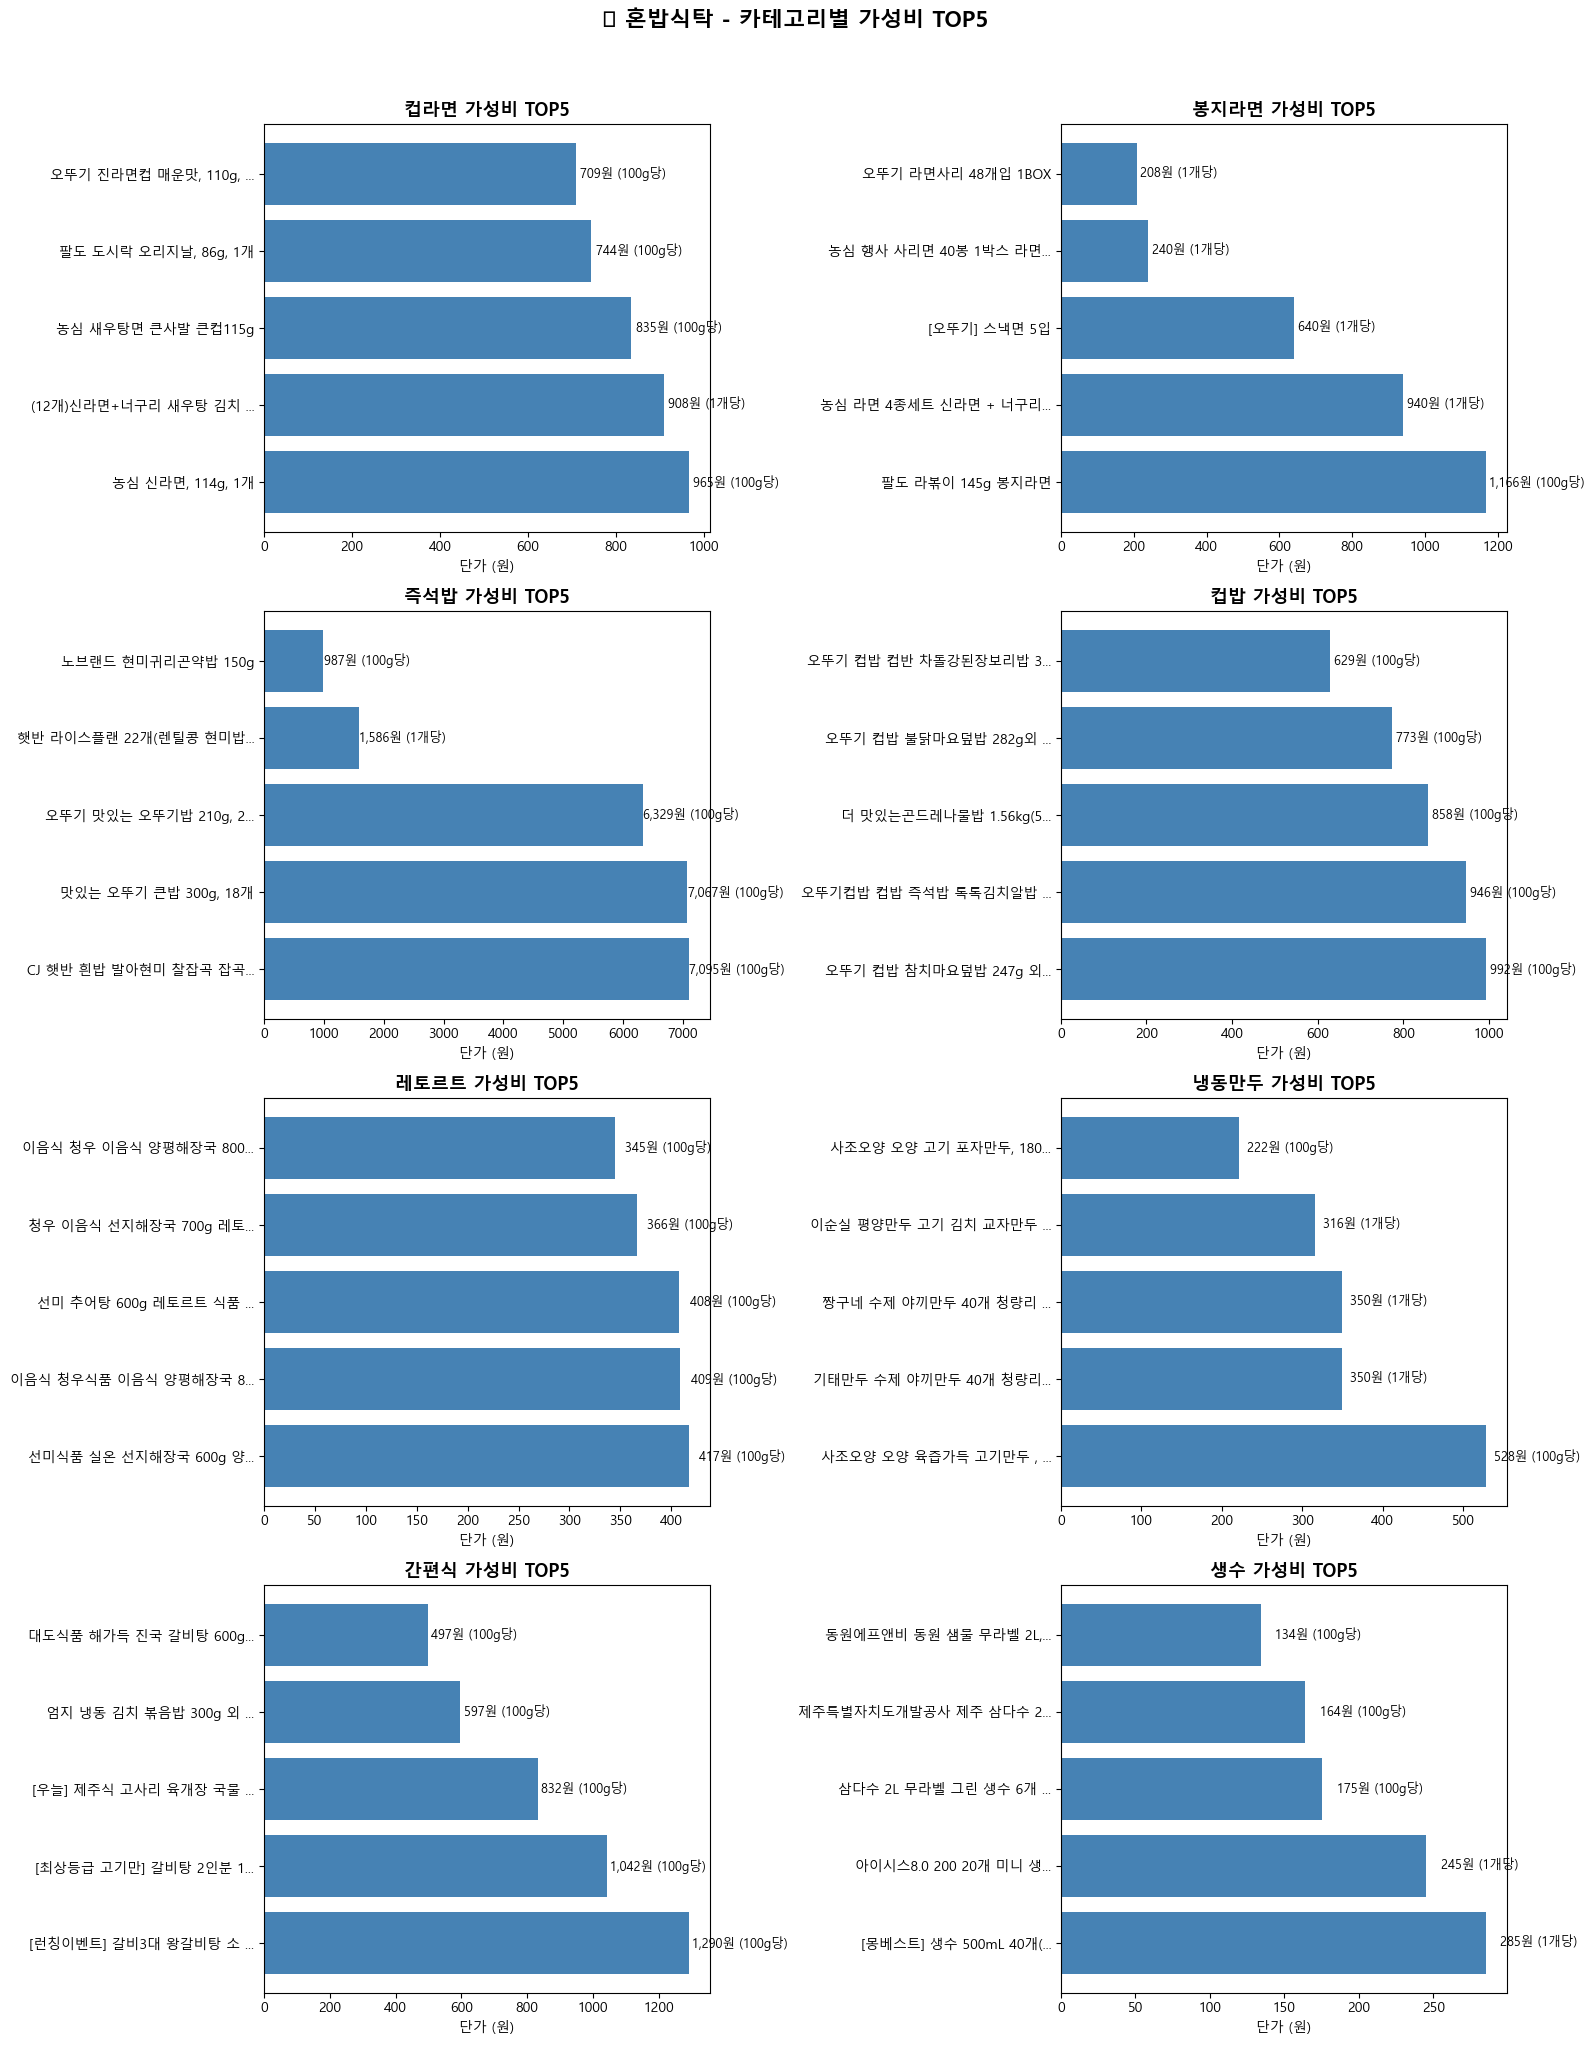

In [65]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, cat in enumerate(df['카테고리'].unique()):
    top5 = df[df['카테고리'] == cat].nsmallest(5, '단가')
    
    # 상품명 20자로 자르기
    labels = top5['상품명'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x)
    
    axes[i].barh(labels, top5['단가'], color='steelblue')
    axes[i].set_title(f'{cat} 가성비 TOP5', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('단가 (원)')
    axes[i].invert_yaxis()  # 1위가 위로
    
    # 단가 값 표시
    for j, (val, basis) in enumerate(zip(top5['단가'], top5['단가기준'])):
        axes[i].text(val + 10, j, f'{int(val):,}원 ({basis})', va='center', fontsize=9)

plt.suptitle('🍱 혼밥식탁 - 카테고리별 가성비 TOP5', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fdfdf

#  -----------------------

# <b> 영양정보 API

In [31]:
#!pip install openpyxl

## <b> 영양정보 데이터 로드 및 전처리

In [46]:
df_food = pd.read_excel(r'C:\IT\workspace_ptyhon\dl\가공식품영양성분.xlsx')
df_food.head(1)

,구분,식품코드,가공식품품목명,대표식품명,식품대분류명,식품중분류명,식품소분류명,영양성분기준용량,에너지\n(kcal),수분\n(g),...,니아신\n(mg),비타민 C\n(mg),비타민 D\n(μg),콜레스테롤\n(mg),포화지방산\n(g),트랜스지방산\n(g),출처명,1회 \n섭취참고량,데이터생성\n방법명,데이터생성일자
0,1,P101_001000100-F001-002,강냉이,강냉이/팝콘,과자류·빵류 또는 떡류,해당없음,과자,100g,450,0.6,...,1.99,0,0,4.17,4.67,0.42,"영양표시, 농진청",20g,수집,2022-12-31


In [33]:
# 컬럼 전체 확인
print(df_food.columns.tolist())
print(f"전체 shape: {df_food.shape}")

['구분', '식품코드', '가공식품품목명', '대표식품명', '식품대분류명', '식품중분류명', '식품소분류명', '영양성분기준용량', '에너지\n(kcal)', '수분\n(g)', '단백질\n(g)', '지방\n(g)', '회분\n(g)', '탄수화물\n(g)', '당류\n(g)', '식이섬유\n(g)', '칼슘\n(mg)', '철\n(mg)', '인\n(mg)', '칼륨\n(mg)', '나트륨\n(mg)', '비타민 A\n(μg RAE)', '레티놀\n(μg)', '베타카로틴\n(μg)', '티아민\n(mg)', '리보플라빈\n(mg)', '니아신\n(mg)', '비타민 C\n(mg)', '비타민 D\n(μg)', '콜레스테롤\n(mg)', '포화지방산\n(g)', '트랜스지방산\n(g)', '출처명', '1회 \n섭취참고량', '데이터생성\n방법명', '데이터생성일자']
전체 shape: (720, 36)


In [48]:
# 필요한 컬럼만 선택
cols = [
    '가공식품품목명',
    '식품대분류명',
    '식품중분류명',
    '영양성분기준용량',
    '에너지\n(kcal)',
    '단백질\n(g)',
    '지방\n(g)',
    '탄수화물\n(g)',
    '나트륨\n(mg)',
    '당류\n(g)',
]

df_food_clean = df_food[cols].copy()

# 컬럼명 정리
df_food_clean.columns = [
    '식품명', '대분류', '중분류', '기준용량',
    '칼로리', '단백질', '지방', '탄수화물', '나트륨', '당류'
]

print(f"영양정보 데이터: {len(df_food_clean)}개")
display(df_food_clean.head())

영양정보 데이터: 720개


,식품명,대분류,중분류,기준용량,칼로리,단백질,지방,탄수화물,나트륨,당류
0,강냉이,과자류·빵류 또는 떡류,해당없음,100g,450,5.00,12,81.00,83,20
1,캐러멜팝콘,과자류·빵류 또는 떡류,해당없음,100g,459,4.77,14.36,77.74,49,34.78
2,튀밥,과자류·빵류 또는 떡류,해당없음,100g,400,20.77,2.31,84.62,154,7.69
3,팝콘,과자류·빵류 또는 떡류,해당없음,100g,460,4.00,16,76.00,280,36
4,도넛/완제품,과자류·빵류 또는 떡류,해당없음,100g,467,5.88,27.45,49.02,529,15.69


In [49]:
# 대분류 어떤 것들 있는지 확인
print(df_food_clean['대분류'].value_counts())

대분류
과자류·빵류 또는 떡류       167
조미식품               114
즉석식품류               70
음료류                 66
농산가공식품류             53
식육가공품 및 포장육         53
수산가공식품류             46
유가공품류               37
절임류 또는 조림류          29
두부류 또는 묵류           16
장류                  15
면류                  12
당류                  11
빙과류                 11
코코아가공품류 또는 초콜릿류      6
알가공품류                6
잼류                   5
식용유지류                2
주류                   1
Name: count, dtype: int64


In [50]:
# 즉석식품류랑 면류 뭐 있는지 확인
target = df_food_clean[df_food_clean['대분류'].isin(['즉석식품류', '면류', '음료류'])]
print(f"관련 데이터: {len(target)}개")
print("\n중분류 확인:")
print(target['중분류'].value_counts())

관련 데이터: 148개

중분류 확인:
중분류
즉석섭취·편의식품류    46
과일·채소류음료      33
만두류           24
해당없음          12
기타음료          12
다류             8
두유류            6
발효음료류          3
커피             2
탄산음료류          2
Name: count, dtype: int64


In [26]:
# API 응답 필드 전체 확인
response = requests.get(url, headers=headers, params={"query": "컵라면", "display": 1})
print(response.json()['items'][0].keys())

dict_keys(['title', 'link', 'image', 'lprice', 'hprice', 'mallName', 'productId', 'productType', 'brand', 'maker', 'category1', 'category2', 'category3', 'category4'])


데이터에(상품명, 링크, 이미지, 최저가, 최고가, 쇼핑몰이름, 상품고유id, 상품유형, 브랜드, 제조사, 대분류, 중분류, 소분류, 세부분류)로 구성<br>
평점이랑 리뷰가 없음 -> 현재의 데이터로 단가,  카테고리로 추천가능

#  -----------------------